# Week 4 Mini Project — Full EDA on the Palmer Penguins Dataset
**Intern:** Sankalpa Parajuli | **Program:** AI/ML Internship | **Week 4 Deliverable**

**Dataset:** Palmer Penguins — physical measurements (bill length/depth, flipper length, body mass)
for 344 penguins of 3 species (Adelie, Chinstrap, Gentoo) across 3 islands in the Palmer Archipelago,
Antarctica. Chosen independently for this week's mini project because it's a real-world biological
dataset with genuine missing values, a mix of numeric and categorical features, and clear
species-level patterns to uncover — a good testbed for a full clean → explore → visualize → summarize
workflow.

**Goal:** Practice the complete EDA workflow independently: load → inspect → clean → explore →
visualize → summarize insights in writing.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('data/penguins_raw.csv')
df.shape


(344, 7)

## 1. Initial Inspection

In [2]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [4]:
df.describe(include='all')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
count,344,344,342.000000,342.000000,342.000000,342.000000,333
unique,3,3,NaN,NaN,NaN,NaN,2
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,Male
freq,152,168,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN
std,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN


### Missing values check

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})


,missing_count,missing_pct
species,0,0.00
island,0,0.00
bill_length_mm,2,0.58
bill_depth_mm,2,0.58
flipper_length_mm,2,0.58
body_mass_g,2,0.58
sex,11,3.20


In [6]:
# Which rows are missing data?
df[df.isna().any(axis=1)]


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


**Observation:** 2 rows are missing *every* numeric measurement and sex (likely a failed/incomplete
record) — these carry no usable information and should be dropped. A further 9 rows are missing only
`sex`, but have complete numeric measurements — these are still useful for the numeric analysis, so
they'll be kept but excluded only from sex-specific comparisons.


## 2. Cleaning

In [7]:
# Drop the 2 fully-empty measurement rows (no usable data at all)
df_clean = df.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']).copy()

print(f"Rows before: {len(df)}  |  Rows after dropping empty-measurement rows: {len(df_clean)}")
print(f"Remaining missing 'sex' values (kept, handled separately): {df_clean['sex'].isna().sum()}")


Rows before: 344  |  Rows after dropping empty-measurement rows: 342
Remaining missing 'sex' values (kept, handled separately): 9


In [8]:
# Standardize categorical text just in case (strip whitespace, consistent casing)
for col in ['species', 'island', 'sex']:
    df_clean[col] = df_clean[col].astype('string').str.strip()

df_clean['sex'] = df_clean['sex'].fillna('Unknown')

df_clean.isna().sum()


species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [9]:
df_clean.to_csv('data/penguins_cleaned.csv', index=False)
df_clean.shape


(342, 7)

## 3. Exploratory Data Analysis

### 3.1 How many penguins per species / island?

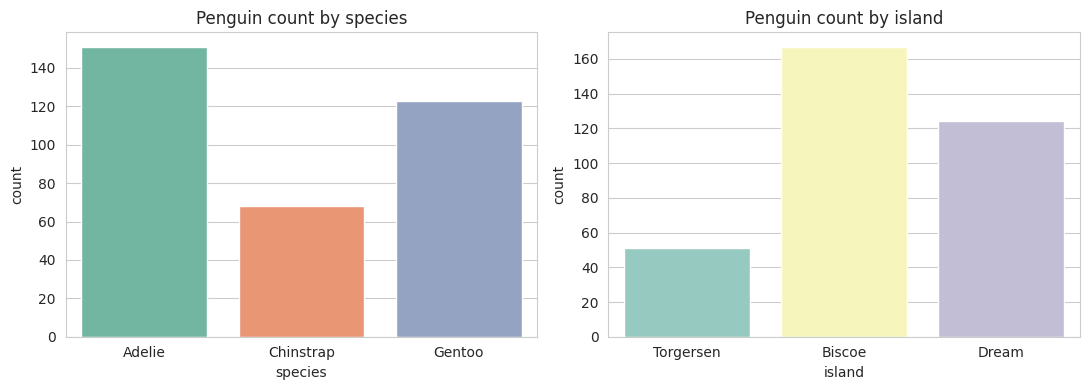

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df_clean, x='species', hue='species', palette='Set2', ax=axes[0], legend=False)
axes[0].set_title('Penguin count by species')

sns.countplot(data=df_clean, x='island', hue='island', palette='Set3', ax=axes[1], legend=False)
axes[1].set_title('Penguin count by island')

plt.tight_layout()
plt.savefig('images/counts.png', dpi=110, bbox_inches='tight')
plt.show()


### 3.2 Distributions of numeric measurements

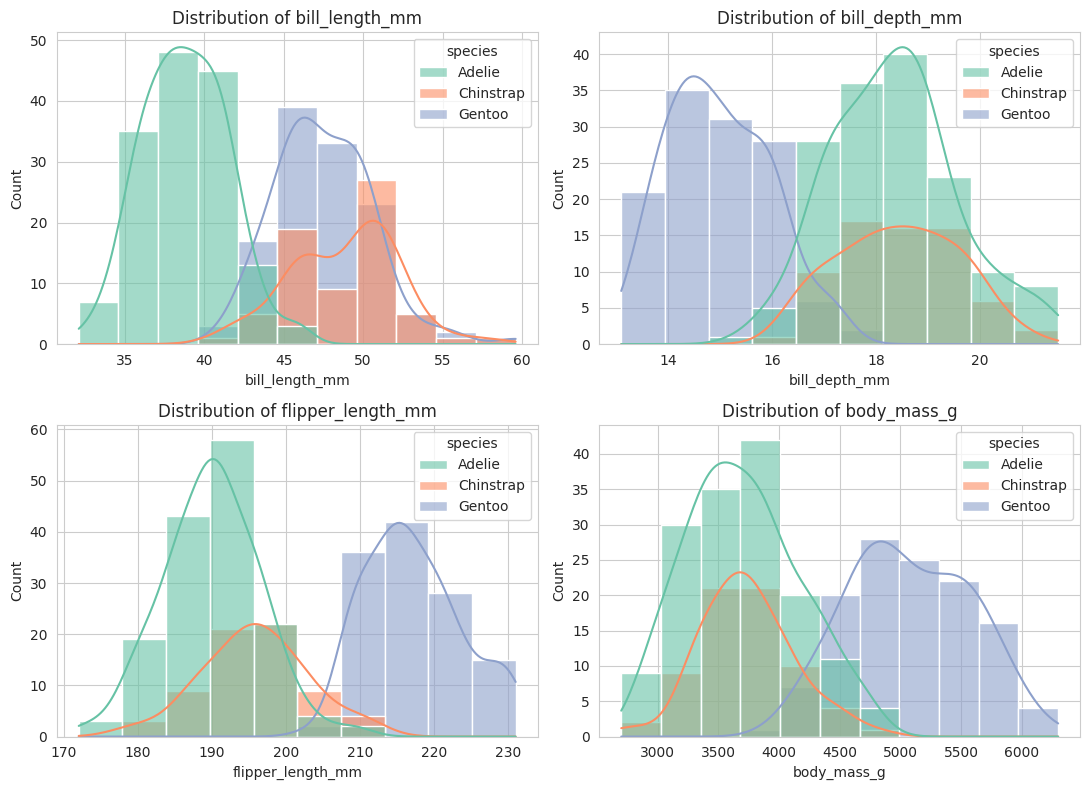

In [11]:
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(data=df_clean, x=col, hue='species', kde=True, palette='Set2', ax=ax, alpha=0.6)
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.savefig('images/distributions_eda.png', dpi=110, bbox_inches='tight')
plt.show()


### 3.3 Do measurements differ by species? (boxplots)

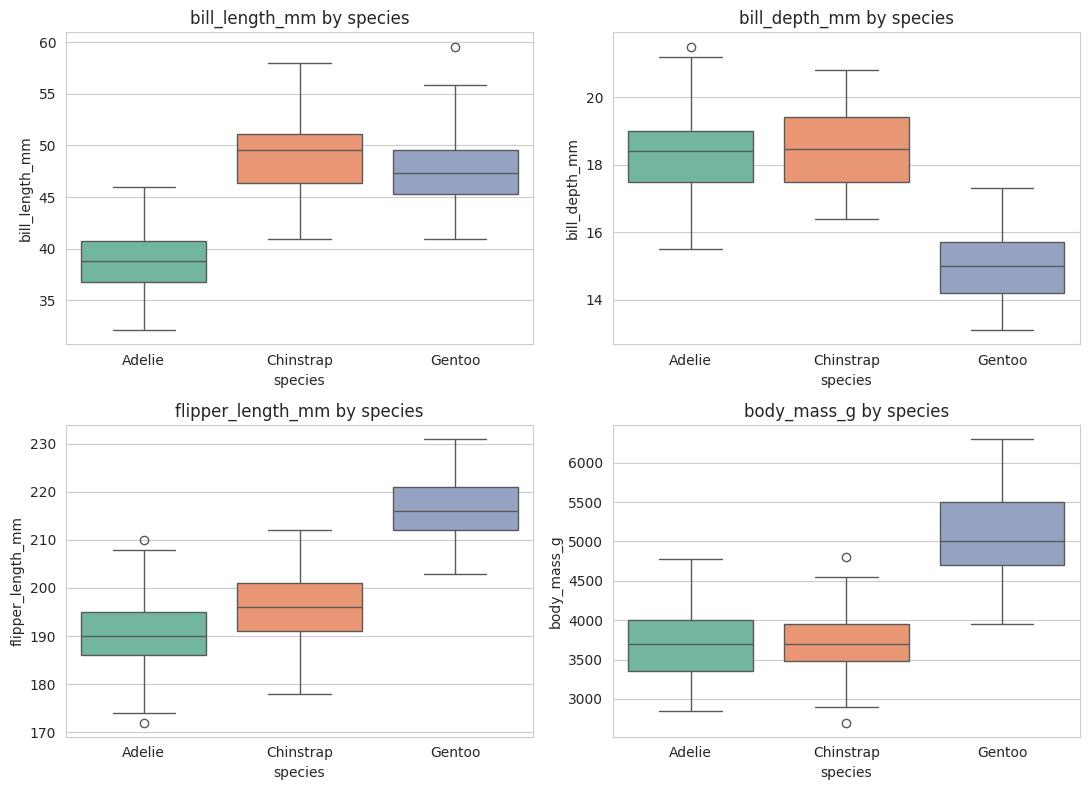

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(data=df_clean, x='species', y=col, hue='species', palette='Set2', ax=ax, legend=False)
    ax.set_title(f'{col} by species')

plt.tight_layout()
plt.savefig('images/boxplots.png', dpi=110, bbox_inches='tight')
plt.show()


### 3.4 Relationships between measurements (pairplot)

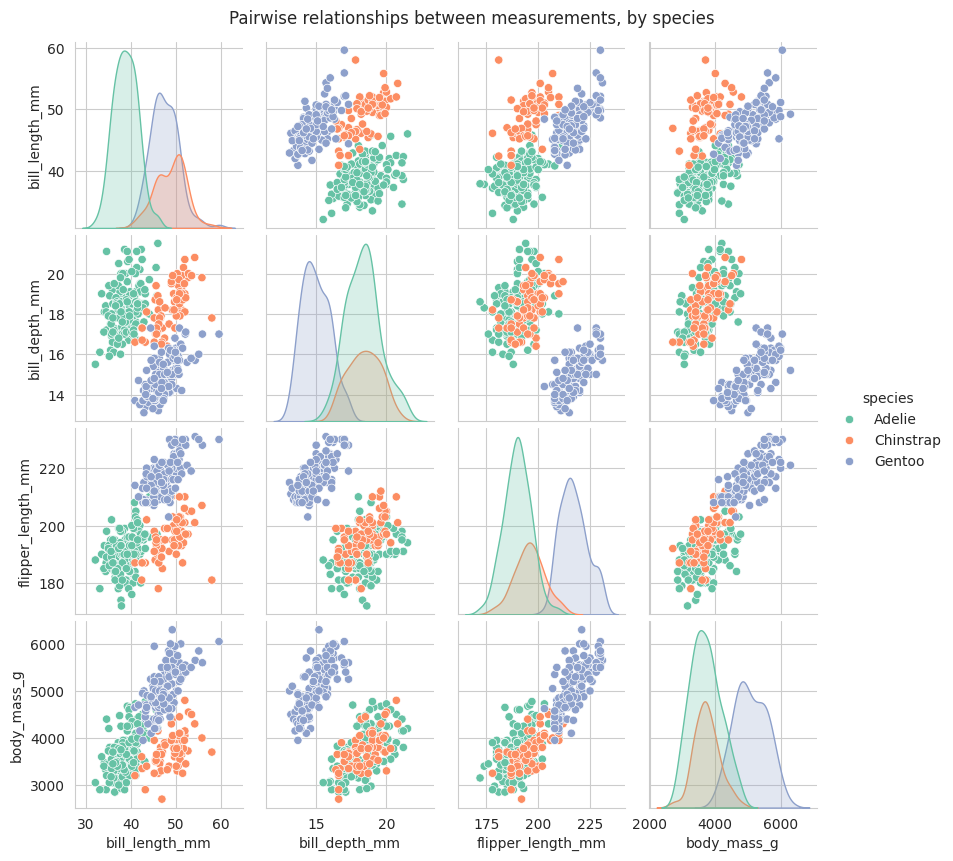

In [13]:
pair = sns.pairplot(df_clean, vars=numeric_cols, hue='species', palette='Set2', diag_kind='kde', height=2.1)
pair.fig.suptitle('Pairwise relationships between measurements, by species', y=1.02)
pair.savefig('images/pairplot.png', dpi=110, bbox_inches='tight')
plt.show()


### 3.5 Correlation between numeric features

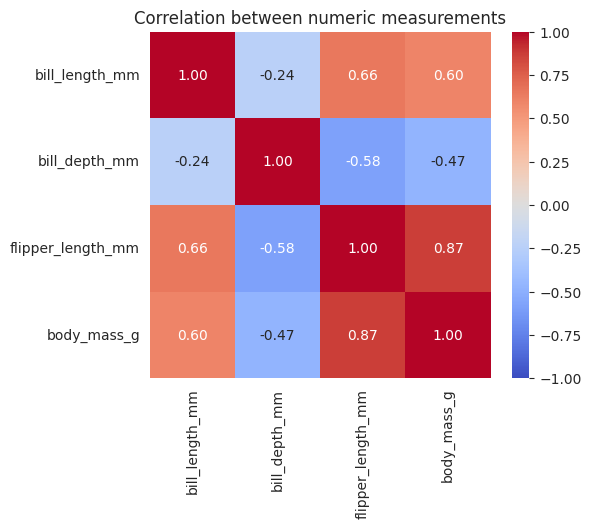

In [14]:
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation between numeric measurements')
plt.savefig('images/correlation.png', dpi=110, bbox_inches='tight')
plt.show()


### 3.6 Body mass by species and sex

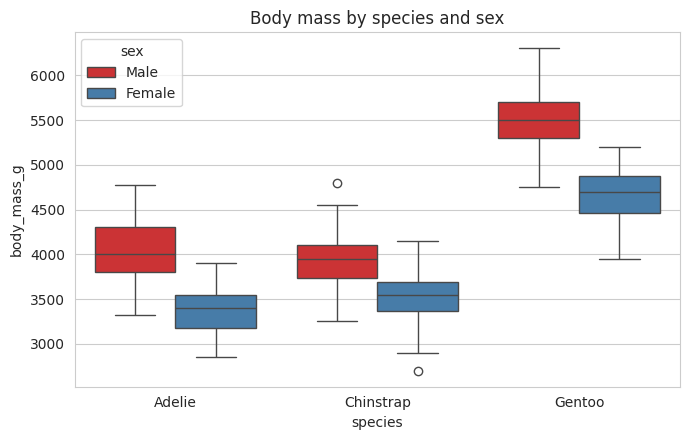

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df_clean[df_clean['sex'] != 'Unknown'], x='species', y='body_mass_g', hue='sex', palette='Set1', ax=ax)
ax.set_title('Body mass by species and sex')
plt.tight_layout()
plt.savefig('images/mass_by_sex.png', dpi=110, bbox_inches='tight')
plt.show()


### 3.7 Groupby summary — average measurements per species

In [16]:
summary = df_clean.groupby('species')[numeric_cols].agg(['mean', 'std']).round(1)
summary


bill_length_mm      bill_depth_mm      flipper_length_mm       \
                    mean  std          mean  std              mean  std   
species                                                                   
Adelie              38.8  2.7          18.3  1.2             190.0  6.5   
Chinstrap           48.8  3.3          18.4  1.1             195.8  7.1   
Gentoo              47.5  3.1          15.0  1.0             217.2  6.5   

          body_mass_g         
                 mean    std  
species                       
Adelie         3700.7  458.6  
Chinstrap      3733.1  384.3  
Gentoo         5076.0  504.1

In [17]:
island_species = pd.crosstab(df_clean['island'], df_clean['species'])
island_species


species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,123
Dream,56,68,0
Torgersen,51,0,0


## 4. Written Summary of Findings

- **Gentoo penguins are the clear outlier in size**: they have the highest body mass (~5,076g avg,
  roughly 1kg heavier than the other two species) and the longest flippers (~217mm avg) — both
  visibly separate from Adelie and Chinstrap in the boxplots and pairplot.
- **Bill shape, not just size, separates species well**: Adelie penguins have short, deep bills
  (short `bill_length_mm`, high `bill_depth_mm`), while Gentoo have long, shallow bills — the
  opposite pattern. This makes `bill_length_mm` vs `bill_depth_mm` one of the cleanest 2-feature
  splits for telling species apart, visible as three well-separated clusters in the pairplot.
- **Flipper length and body mass are strongly positively correlated** (from the heatmap), which
  makes biological sense — larger-bodied penguins need proportionally larger flippers for swimming.
  Bill depth is only weakly correlated with the other measurements.
- **Islands are not evenly mixed**: Gentoo penguins were only recorded on Biscoe island, and
  Chinstrap only on Dream island, while Adelie appear on all three islands (Torgersen, Biscoe, and
  Dream). Species and island are therefore not independent in this dataset — something to keep in
  mind if `island` is ever used as a feature, since it partially leaks species identity.
- **Sex differences exist but are smaller than species differences**: within every species, males
  are consistently heavier and have longer/deeper bills than females, but the male/female
  distributions still overlap a lot more than the species distributions do — species is the dominant
  driver of size in this dataset, sex is a secondary effect.
- **Cleaning impact was minor**: only 2 of 344 rows (0.6%) had to be dropped for being entirely empty
  on the measurement columns; the remaining 9 rows with unknown `sex` were kept for numeric analysis
  since dropping them would have discarded otherwise complete data.

**Conclusion:** even with just 4 numeric measurements and no modelling yet, species is very clearly
separable by eye — which is a good sign that a simple classifier (something to try in later weeks)
should perform well on this dataset.
